# DAY2 — 핵심 Feature 대체와 용량 급등값 처리 비교

기존 기준은 ΔQ 분산 하나로 변환하지 않은 전체 수명 cycle_life를 예측하는 Linear Regression이다. 같은 개발 29개·고정 CV에서 ΔQ 분산을 최솟값으로 교체하고, 용량 기울기를 추가한 경우 급등값 유지/masking 조건을 비교한다.

Feature는 모델 입력, Target은 정답이다. 이번에는 Target을 변환하지 않는다. 분산은 기존 log10 값을 사용하고 최솟값은 부호를 포함한 원래 값을 사용한다. 따라서 통계 선택과 그 표현을 함께 비교한 실험이다. Hold-out과 Batch 2는 평가하지 않는다.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/day2_feature_comparison.py').is_file())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.day2_feature_comparison import FEATURE_SETS, configurations, paired_fold_deltas, save_figures
from src.day2_linear_comparison import evaluate
train = pd.read_parquet(ROOT / 'data/processed/day2/train_batch1.parquet')
development = train.loc[train.partition.eq('development')].sort_values(['batch','cell_id']).reset_index(drop=True)
print('커널:', sys.executable)
print('개발 항목:', len(development))

커널: /Users/soobin/myfolder/workspace/mini-project-data-analysis/.venv/bin/python
개발 항목: 29


## 1. 비교 구성을 먼저 확인

분산은 전압별 차이값이 퍼진 정도, 최솟값은 그 차이값 중 가장 작은 값이다. 두 값은 같은 ΔQ 곡선에서 계산됐으며 이미 저장된 표를 재사용한다. 둘을 동시에 입력하지 않는다.

`variance_only`: 분산만, `minimum_only`: 최솟값만. `_retained`는 용량 급등값을 유지한 기울기 추가, `_masked`는 1.32 Ah 초과 값을 가린 기울기 추가다. 각 조합에서 Linear Regression, Ridge alpha=0.1·10을 비교한다. 이번에는 alpha 탐색 범위를 추가하지 않는다.

In [2]:
display(pd.DataFrame([{'입력 조합': key, 'Feature 열': ', '.join(value)} for key, value in FEATURE_SETS.items()]))
configs = list(configurations())
assert len(configs) == 18
display(pd.DataFrame(configs))

,입력 조합,Feature 열
0,variance_only,log10_deltaQ_var
1,minimum_only,deltaQ_min
2,variance_retained,"log10_deltaQ_var, QD_slope_retained"
3,variance_masked,"log10_deltaQ_var, QD_slope_masked"
4,minimum_retained,"deltaQ_min, QD_slope_retained"
5,minimum_masked,"deltaQ_min, QD_slope_masked"


,config_id,model,feature_set,target,alpha
0,ols_variance_only,ols,variance_only,raw,NaN
1,ridge_variance_only_a0.1,ridge,variance_only,raw,0.1
2,ridge_variance_only_a10,ridge,variance_only,raw,10.0
3,ols_minimum_only,ols,minimum_only,raw,NaN
4,ridge_minimum_only_a0.1,ridge,minimum_only,raw,0.1
5,ridge_minimum_only_a10,ridge,minimum_only,raw,10.0
6,ols_variance_retained,ols,variance_retained,raw,NaN
7,ridge_variance_retained_a0.1,ridge,variance_retained,raw,0.1
8,ridge_variance_retained_a10,ridge,variance_retained,raw,10.0
9,ols_variance_masked,ols,variance_masked,raw,NaN


## 2. 실제로 기울기가 바뀐 셀 확인

In [3]:
changed = ~np.isclose(development.QD_slope_retained, development.QD_slope_masked, rtol=1e-10, atol=1e-12)
display(development.loc[changed, ['cell_id','barcode_key','cv_valid_fold','early_high_QD_rows','QD_slope_retained','QD_slope_masked']])
assert development.loc[changed,'cell_id'].tolist() == [18]

,cell_id,barcode_key,cv_valid_fold,early_high_QD_rows,QD_slope_retained,QD_slope_masked
6,18,EL150800453240,1,1,-0.000496,-0.000062


## 3. 같은 CV로 학습·검증

In [4]:
summary, fold_scores, oof_predictions, coefficients, scaler_statistics = evaluate(development, configs, FEATURE_SETS)
deltas = paired_fold_deltas(fold_scores)
assert len(fold_scores) == 90 and len(oof_predictions) == 18 * 29
assert not oof_predictions.duplicated(['config_id','barcode_key']).any()
display(summary)
TABLES = ROOT / 'outputs/tables/day2/feature_comparison'
if (TABLES / 'summary.csv').exists():
    saved = pd.read_csv(TABLES / 'summary.csv')
    np.testing.assert_allclose(summary.mean_fold_mape_pct, saved.mean_fold_mape_pct, rtol=1e-12)
    print('재실행 결과와 저장 결과 일치')

,config_id,model,feature_set,target,alpha,mean_fold_mape_pct,std_fold_mape_pct,worst_fold_mape_pct,mean_fold_mae_cycles,mean_fold_rmse_cycles,pooled_oof_mape_pct,oof_n,nonpositive_prediction_n
0,ridge_variance_only_a0.1,ridge,variance_only,raw,0.1,8.612355,2.001813,10.985726,69.840220,88.027896,8.650342,29,0
1,ols_variance_only,ols,variance_only,raw,NaN,8.616772,1.991773,10.996753,69.889489,88.078260,8.656105,29,0
2,ridge_minimum_only_a0.1,ridge,minimum_only,raw,0.1,8.849489,2.263938,11.668119,70.784324,87.849838,8.897843,29,0
3,ols_minimum_only,ols,minimum_only,raw,NaN,8.885787,2.234146,11.682113,71.006043,87.934068,8.931277,29,0
4,ridge_minimum_only_a10,ridge,minimum_only,raw,10.0,9.188595,2.135773,12.009585,72.703787,89.262007,9.238553,29,0
5,ridge_minimum_masked_a10,ridge,minimum_masked,raw,10.0,9.344748,2.724231,12.518028,74.190960,90.634638,9.445168,29,0
6,ridge_variance_only_a10,ridge,variance_only,raw,10.0,9.564892,1.815608,11.689290,74.556602,91.247793,9.536514,29,0
7,ridge_minimum_retained_a10,ridge,minimum_retained,raw,10.0,9.917883,2.314362,12.059023,77.465072,95.533352,10.000482,29,0
8,ridge_variance_retained_a0.1,ridge,variance_retained,raw,0.1,9.937854,2.273569,12.695271,78.903277,97.682871,10.023394,29,0
9,ridge_variance_masked_a10,ridge,variance_masked,raw,10.0,9.975645,2.036165,12.313670,77.655634,93.542505,9.979811,29,0


재실행 결과와 저장 결과 일치


## 4. Feature 교체의 효과

최솟값으로 바꾼 경우 분산을 사용하는 기준보다 확실한 개선이 없었다. Ridge alpha=10에서는 최솟값이 더 나았으므로 특정 규제 강도의 결과만으로 통계 전체의 우열을 확정하지 않는다. 다음 모델 비교의 기준 Feature는 분산 하나로 유지한다.

In [5]:
single = summary.loc[summary.feature_set.isin(['variance_only','minimum_only'])]
display(single)
display(deltas.loc[deltas.comparison.eq('descriptor_replacement')])

,config_id,model,feature_set,target,alpha,mean_fold_mape_pct,std_fold_mape_pct,worst_fold_mape_pct,mean_fold_mae_cycles,mean_fold_rmse_cycles,pooled_oof_mape_pct,oof_n,nonpositive_prediction_n
0,ridge_variance_only_a0.1,ridge,variance_only,raw,0.1,8.612355,2.001813,10.985726,69.840220,88.027896,8.650342,29,0
1,ols_variance_only,ols,variance_only,raw,NaN,8.616772,1.991773,10.996753,69.889489,88.078260,8.656105,29,0
2,ridge_minimum_only_a0.1,ridge,minimum_only,raw,0.1,8.849489,2.263938,11.668119,70.784324,87.849838,8.897843,29,0
3,ols_minimum_only,ols,minimum_only,raw,NaN,8.885787,2.234146,11.682113,71.006043,87.934068,8.931277,29,0
4,ridge_minimum_only_a10,ridge,minimum_only,raw,10.0,9.188595,2.135773,12.009585,72.703787,89.262007,9.238553,29,0
6,ridge_variance_only_a10,ridge,variance_only,raw,10.0,9.564892,1.815608,11.689290,74.556602,91.247793,9.536514,29,0


,comparison,model,alpha,fold,base_feature_set,alternative_feature_set,base_mape_pct,alternative_mape_pct,alternative_minus_base_pp
0,descriptor_replacement,ols,NaN,1,variance_only,minimum_only,6.493499,7.089363,0.595864
1,descriptor_replacement,ols,NaN,2,variance_only,minimum_only,10.996753,11.682113,0.685360
2,descriptor_replacement,ols,NaN,3,variance_only,minimum_only,7.643788,7.157602,-0.486186
3,descriptor_replacement,ols,NaN,4,variance_only,minimum_only,10.473711,10.933265,0.459554
4,descriptor_replacement,ols,NaN,5,variance_only,minimum_only,7.476106,7.566593,0.090487
5,descriptor_replacement,ridge,0.1,1,variance_only,minimum_only,6.449655,7.042939,0.593285
6,descriptor_replacement,ridge,0.1,2,variance_only,minimum_only,10.985726,11.668119,0.682393
7,descriptor_replacement,ridge,0.1,3,variance_only,minimum_only,7.624592,7.140510,-0.484081
8,descriptor_replacement,ridge,0.1,4,variance_only,minimum_only,10.491077,10.948641,0.457564
9,descriptor_replacement,ridge,0.1,5,variance_only,minimum_only,7.510724,7.447236,-0.063488


## 5. masking의 효과

`alternative_minus_base_pp`는 masking 오차 − 유지 조건 오차다. 음수는 masking 조건에서 오차가 감소했다는 뜻이다. 효과는 대표 ΔQ 통계와 Ridge alpha에 따라 다르다. 하나의 셀 값 변화가 그 셀의 검증 예측뿐 아니라, 그 셀이 학습에 포함된 다른 회차의 계수도 바꿀 수 있다.

In [6]:
display(deltas.groupby(['comparison','model','alpha'],dropna=False).alternative_minus_base_pp.mean().to_frame('평균 MAPE 차이 (%p)'))
ids = ['ols_variance_retained','ols_variance_masked','ols_minimum_retained','ols_minimum_masked']
display(oof_predictions.loc[oof_predictions.cell_id.eq(18) & oof_predictions.config_id.isin(ids), ['config_id','fold','actual_life','predicted_life','ape_pct']])
display(coefficients.loc[coefficients.config_id.isin(ids)])

평균 MAPE 차이 (%p)
comparison             model alpha                 
descriptor_replacement ols   NaN           0.269016
                       ridge 0.1           0.237134
                             10.0         -0.376297
masking_minimum        ols   NaN          -2.109111
                       ridge 0.1          -1.937643
                             10.0         -0.573135
masking_variance       ols   NaN           1.278584
                       ridge 0.1           1.314396
                             10.0         -0.677917

,config_id,fold,actual_life,predicted_life,ape_pct
174,ols_variance_retained,1,691.0,927.004503,34.154053
261,ols_variance_masked,1,691.0,713.834059,3.304495
348,ols_minimum_retained,1,691.0,1282.790663,85.642643
435,ols_minimum_masked,1,691.0,762.212750,10.305753


,config_id,model,feature_set,target,alpha,fold,feature,coefficient_scaled_input,coefficient_original_input,intercept_scaled_input,intercept_original_input
30,ols_variance_retained,ols,variance_retained,raw,NaN,1,log10_deltaQ_var,-116.565823,-5.472831e+02,785.782609,-1314.418614
31,ols_variance_retained,ols,variance_retained,raw,NaN,1,QD_slope_retained,-17.363580,-4.916344e+05,785.782609,-1314.418614
32,ols_variance_retained,ols,variance_retained,raw,NaN,2,log10_deltaQ_var,-113.204188,-4.899267e+02,782.913043,-1061.041024
33,ols_variance_retained,ols,variance_retained,raw,NaN,2,QD_slope_retained,8.006047,7.844817e+04,782.913043,-1061.041024
34,ols_variance_retained,ols,variance_retained,raw,NaN,3,log10_deltaQ_var,-101.629080,-4.613081e+02,765.304348,-962.505548
35,ols_variance_retained,ols,variance_retained,raw,NaN,3,QD_slope_retained,5.525024,5.417861e+04,765.304348,-962.505548
36,ols_variance_retained,ols,variance_retained,raw,NaN,4,log10_deltaQ_var,-91.544972,-3.993514e+02,753.000000,-742.364616
37,ols_variance_retained,ols,variance_retained,raw,NaN,4,QD_slope_retained,6.282738,6.124706e+04,753.000000,-742.364616
38,ols_variance_retained,ols,variance_retained,raw,NaN,5,log10_deltaQ_var,-95.487770,-5.101957e+02,798.958333,-1145.022059
39,ols_variance_retained,ols,variance_retained,raw,NaN,5,QD_slope_retained,1.438274,1.471084e+04,798.958333,-1145.022059


## 6. 결과 그래프

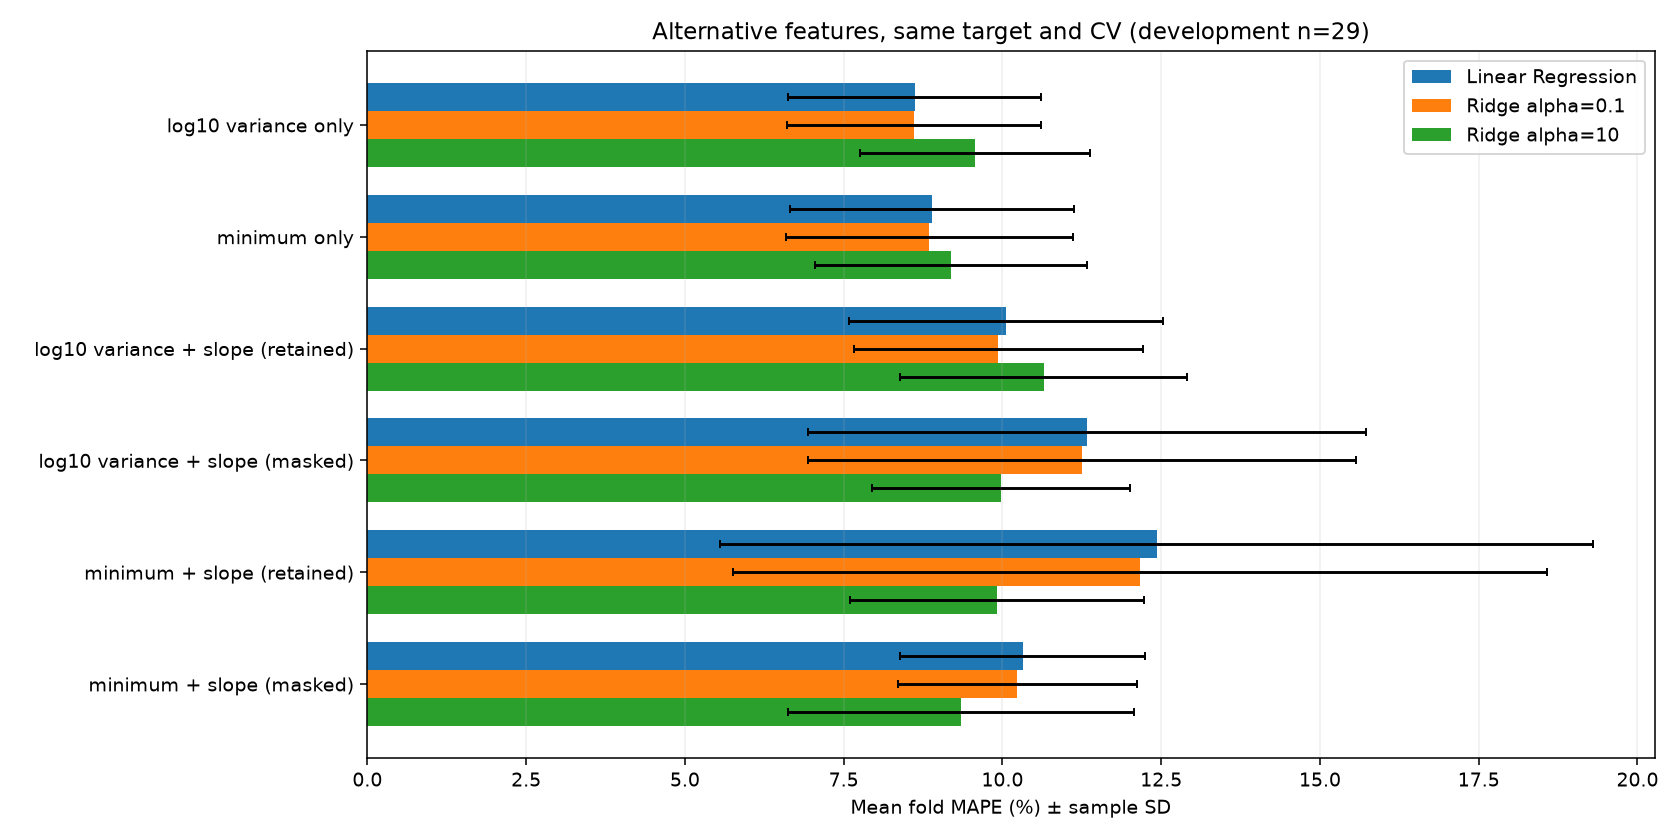

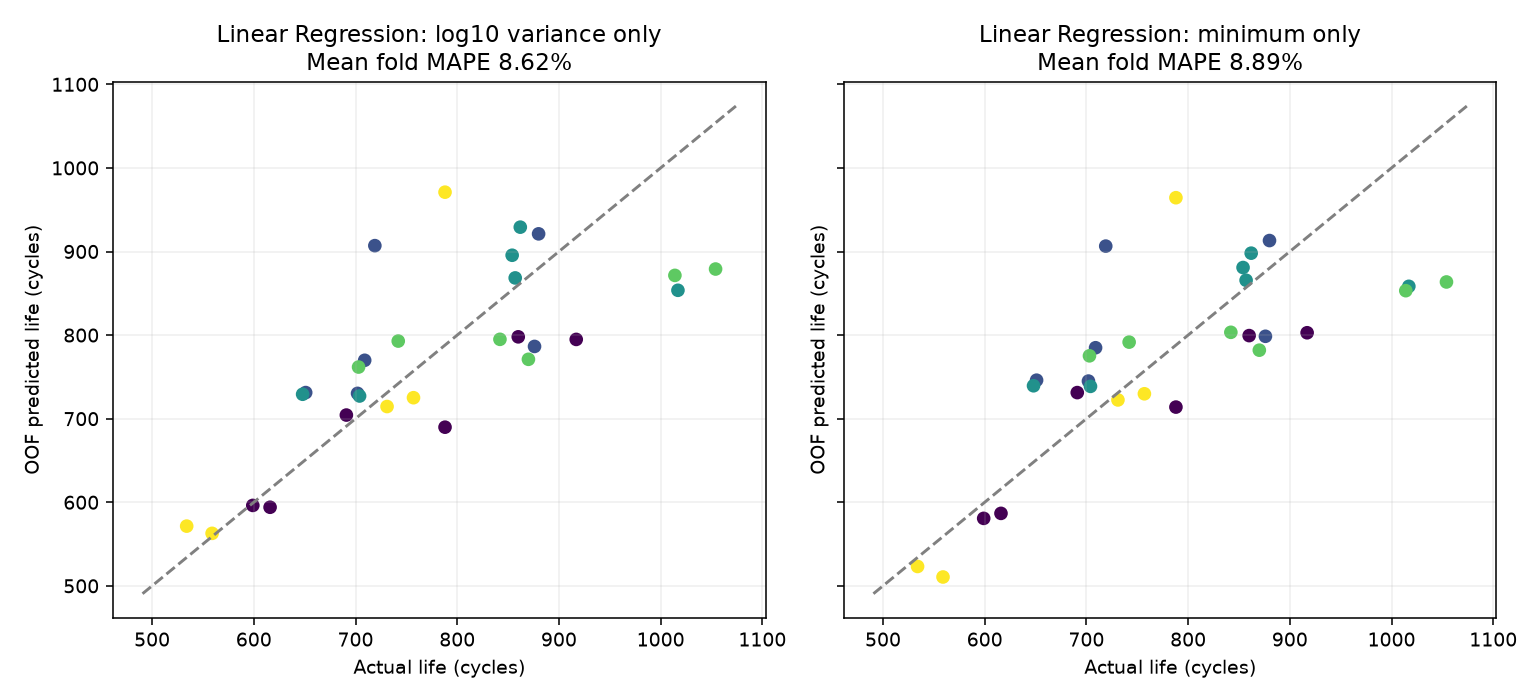

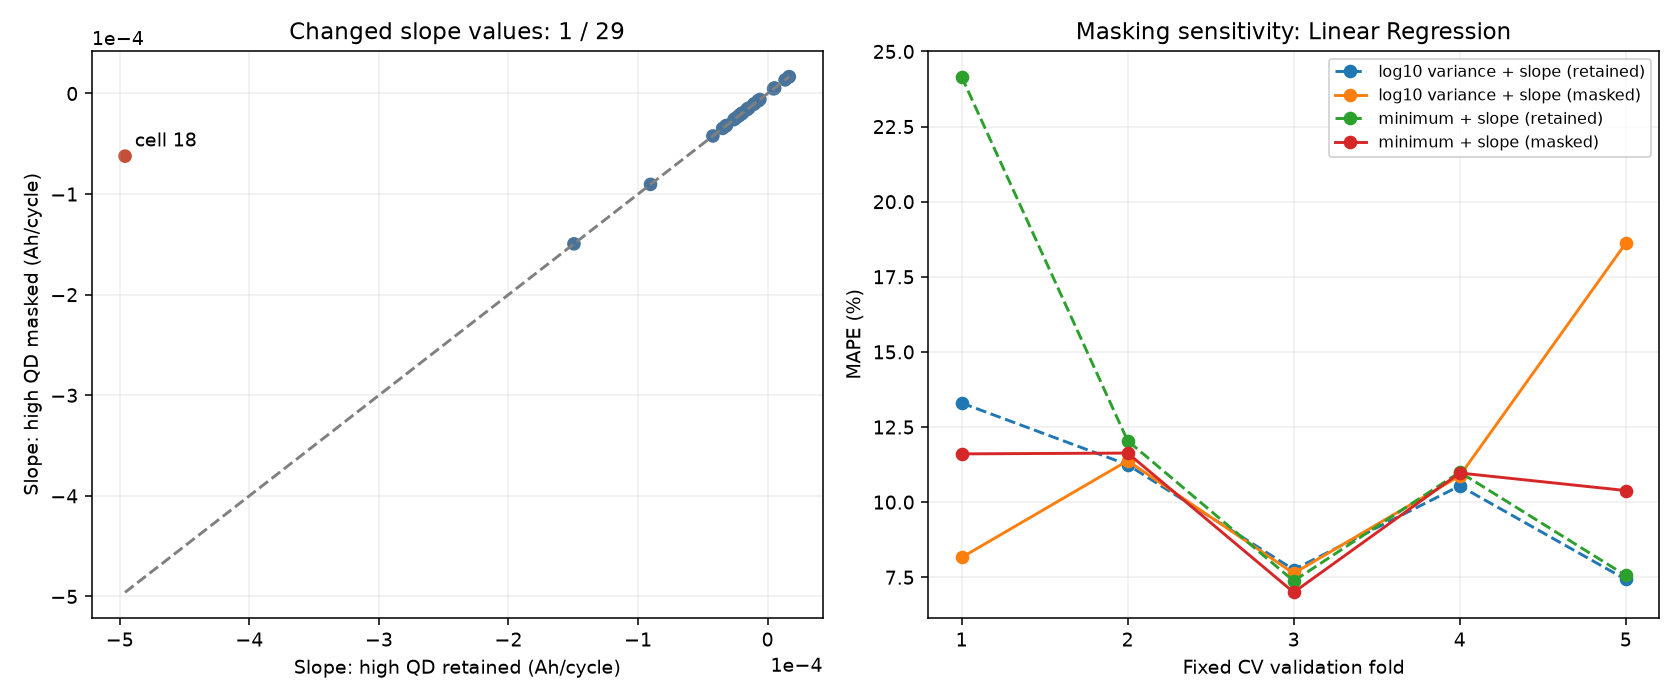

In [7]:
save_figures(development, summary, fold_scores, oof_predictions)
FIGURES = ROOT / 'outputs/figures/day2/feature_comparison'
for file in ['01_feature_comparison.png','02_descriptor_predictions.png','03_masking_sensitivity.png']:
    display(Image(filename=str(FIGURES / file)))

## 7. 유지·교체 결정

- **ΔQ 분산 하나 + 변환하지 않은 수명 + Linear Regression**을 다음 비교의 기준으로 유지한다.
- ΔQ 최솟값은 교체를 확정하지 않고 대체 후보로 보존한다. 현재 분할에서 전체적으로 더 낫다는 근거가 부족하다.
- 용량 기울기는 이번 실험에서도 단일 Feature 기준보다 좋은 구성이 되지 않아 기본 입력에 추가하지 않는다.
- masking은 값의 이상 여부를 검토하는 기준과 예측 효과를 구분한다. CV 점수만 보고 원본 값을 오류로 확정하거나, masking이 항상 성능을 개선한다고 주장하지 않는다.
- 다음은 같은 Feature·Target·CV에서 Linear Regression과 제한된 Gradient Boosting 모델을 비교하는 단계다.

[비교 보고서](../outputs/reports/day2/feature_comparison_report.md) · [실험 코드](../src/day2_feature_comparison.py)